# 3D simple perturbation: K-Order Liénard–Wiechert correction

The zeroth-order trajectory is the exact motion of a single charge in the
constant longitudinal external field `E_Z`.  The first-order perturbation
in position and momentum is then obtained by integrating the
Liénard–Wiechert fields produced by all *other* macroparticles along that
zeroth-order trajectory.

## Unit conventions

A hybrid unit system is used for the dynamical variables:

- length          : m
- time            : s
- mass            : MeV / c²
- momentum        : MeV / c
- charge          : units of the elementary-charge magnitude `|e|`
- electric field  : MV / m

`calc_LW_fields` temporarily switches to pure SI (coulombs, volts per
metre, tesla) to evaluate the electromagnetic field formulas; the
returned force is converted back to the hybrid system before being fed
into the state-vector derivative.  Momenta are converted to the
dimensionless `β·γ` only for plotting.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import qmc
from scipy.integrate import solve_ivp

from joblib import Parallel, delayed

plt.rcParams["font.family"] = "serif"

In [2]:
# ---------------------------------------------------------------------
# Physical constants
# ---------------------------------------------------------------------
C_SI         = 299_792_458          # speed of light                    [m/s]
EPSILON_0_SI = 8.8541878128e-12     # vacuum permittivity               [A·s/(V·m)]
E_CHARGE_SI  = 1.602176634e-19      # elementary charge magnitude |e|   [C]
M_E_SI       = 9.1093837015e-31     # electron rest mass                [kg]
M_E          = 0.511                # electron rest mass                [MeV/c²]
Q_E          = -1.0                 # electron charge                   [|e|]

In [3]:
# ---------------------------------------------------------------------
# Simulation parameters
# ---------------------------------------------------------------------
E_Z              = -1.0              # longitudinal external E-field     [MV/m]
TOTAL_CHARGE_SI  = -1e-12            # total bunch charge                [C]
N_PARTICLES      = 2**8              # number of macroparticles          [1]
T_END            = 3e-9              # end of integration                [s]

USE_CIC_SOFTENING = True             # whether to use softening in the CIC force calculation
R_SOFT = 0.00005                     # softening radius for CIC (if enabled)  [m]

# ---------------------------------------------------------------------
# TPSA perturbation parameters
# ---------------------------------------------------------------------
PERTURB_ORDER = 4                   # maximum perturbation order K       [1]
NUM_STEPS     = 800                 # number of fixed time steps         [1]

# ---------------------------------------------------------------------
# TPSA perturbation parameters
# ---------------------------------------------------------------------

N_LOWER_ORDERS_TO_PLOT = PERTURB_ORDER-1 # Set to 0 to plot only the K-th order curve (in which case reference-data difference is shown)

# ---------------------------------------------------------------------
# Time-stepping loop (parallel kernels per step).
#   INTEGRATOR = "euler" -> explicit Euler, 1 derivative eval per step,    O(dt)
#   INTEGRATOR = "heun"  -> RK2 predictor-corrector, 2 evals per step,     O(dt^2)
# ---------------------------------------------------------------------
INTEGRATOR = "euler"

# ---------------------------------------------------------------------
# Derived quantities
# ---------------------------------------------------------------------
N_REAL_PARTICLES = np.abs(TOTAL_CHARGE_SI) / E_CHARGE_SI    # real electrons in the bunch
MACRO_WEIGHT     = N_REAL_PARTICLES / N_PARTICLES           # real particles per macroparticle

# Signed macroparticle charge / mass for the pure-SI L-W field calculation.
Q_MACRO_SI = Q_E * MACRO_WEIGHT * E_CHARGE_SI               # [C]
M_MACRO_SI = MACRO_WEIGHT * M_E_SI                          # [kg]

In [4]:
def p_to_betagamma(p):
    """Convert momentum from [MeV/c] to the dimensionless ``β·γ``.

    Parameters
    ----------
    p : array_like
        Momentum in MeV/c.

    Returns
    -------
    array_like
        Same shape as ``p``, dimensionless.
    """
    return p / M_E


def sample_ellipsoid_qmc(mean, radii, n_particles):
    """Quasi-Monte-Carlo sampling of a 3D ellipsoid using a Sobol sequence.

    Produces a low-discrepancy, clump-free, uniform-density set of points
    inside the ellipsoid centred at ``mean`` with semi-axes ``radii``.

    Parameters
    ----------
    mean : array_like, shape (3,)
        Centre of the ellipsoid [m].
    radii : array_like, shape (3,)
        Semi-axis lengths [m].
    n_particles : int
        Number of samples (best results when this is a power of two).

    Returns
    -------
    points : ndarray, shape (n_particles, 3)
        Sampled positions [m].
    """
    sampler = qmc.Sobol(d=3, scramble=False)
    u = sampler.random(n=n_particles)
    u1, u2, u3 = u[:, 0], u[:, 1], u[:, 2]

    # Uniform density inside the unit ball: r ~ u1^(1/3) absorbs the radial
    # Jacobian; cos(θ) uniform in [-1, 1] gives a uniform direction.
    r         = u1 ** (1.0 / 3.0)
    cos_theta = 1.0 - 2.0 * u2
    sin_theta = np.sqrt(1.0 - cos_theta ** 2)
    phi       = 2.0 * np.pi * u3

    x_sphere = r * sin_theta * np.cos(phi)
    y_sphere = r * sin_theta * np.sin(phi)
    z_sphere = r * cos_theta

    points = np.empty((n_particles, 3))
    points[:, 0] = mean[0] + radii[0] * x_sphere
    points[:, 1] = mean[1] + radii[1] * y_sphere
    points[:, 2] = mean[2] + radii[2] * z_sphere
    return points

In [5]:
# Reference-simulation data.
#   column  0     time           [s]
#   columns 1..3  mean position  (x, y, z)   [m]
#   columns 4..6  position sigma (x, y, z)   [m]
#   columns 7..9  mean momentum  (x, y, z)   [MeV/c]
data_3d_simple = np.loadtxt("./data/3d_data_simple.csv", delimiter=",")

data_times = data_3d_simple[:, 0]
data_position_means_si  = data_3d_simple[:, 1:4]    # [m]
data_position_sigmas_si = data_3d_simple[:, 4:7]    # [m]
data_momentum_means_pp  = data_3d_simple[:, 7:10]   # [MeV/c]
data_momentum_sigmas_pp = data_3d_simple[:, 10:]    # [MeV/c]

def plot_data(ax, x_analytic, y_analytic, x_data, y_data, plot_diff=True):
    y_data_interp = np.interp(x_analytic, x_data, y_data)

    ax.plot(x_analytic, y_data_interp, label="Simulation Data", color="black", linestyle="--", linewidth=0.5)
    ax.legend(loc="upper left")

    if not plot_diff:
        return

    ax_diff = ax.twinx()
    y_diff = np.abs(y_data_interp - y_analytic)
    ax_diff.plot(x_analytic, y_diff, label="Difference \nSimulation - Analytic", color="red", linewidth=0.5)
    ax_diff.set_ylabel(ax.get_ylabel(), color="red")
    ax_diff.tick_params(axis='y', labelcolor="red")
    ax_diff.legend(loc="upper right")

# K-order Liénard–Wiechert perturbation via TPSA

The perturbation hierarchy is unrolled to arbitrary order $K$ using a
lightweight **Truncated Power Series Algebra** (TPSA) layer compiled with
`numba.njit`:

* every scalar / 3-vector dynamical quantity is stored as a length-$K{+}1$
  array of $\varepsilon$-coefficients
  $f(\varepsilon)=f^{(0)}+\varepsilon f^{(1)}+\dots+\varepsilon^{K}f^{(K)}$;
* the self-field is tagged with one extra factor of $\varepsilon$, so the
  $\varepsilon^k$ coefficient of the equations of motion reproduces the
  classical $k$-th order perturbation (matching `equations.txt`);
* the per-step kernel is parallelised over the target trajectories via
  `numba.prange`;
* the per-pair retarded time is itself a TPSA scalar: a robust scalar
  Newton solve fixes the $\varepsilon^0$ part, after which a few
  TPSA-Newton refinement iterations bring all higher orders in.

The 0-th-order trajectory is overwritten by its closed-form
external-field solution at the end of every step, so only the genuine
perturbative orders $k\!\ge\!1$ accumulate Euler error.  RK-style
stepping is straightforward in the same TPSA ring but adds intra-step
source-history bookkeeping; we stick with explicit Euler for clarity.

In [6]:
import numpy as np
from numba import njit, prange

# TPSA convention
#   scalar  : shape (K+1,)        -- coefficients of 1, eps, eps^2, ..., eps^K
#   3-vector: shape (K+1, 3)      -- one TPSA scalar per Cartesian component
# Every operation writes into a caller-supplied ``out`` buffer to keep the
# kernel allocation-free.

@njit(cache=True, fastmath=True)
def tp_mul(a, b, out):                       # out = a * b   (Cauchy product)
    K1 = a.shape[0]
    for n in range(K1):
        s = 0.0
        for m in range(n + 1):
            s += a[m] * b[n - m]
        out[n] = s

@njit(cache=True, fastmath=True)
def tp_inv(a, out):                          # out = 1 / a   (a[0] != 0)
    K1 = a.shape[0]
    out[0] = 1.0 / a[0]
    for n in range(1, K1):
        s = 0.0
        for m in range(1, n + 1):
            s += a[m] * out[n - m]
        out[n] = -out[0] * s

@njit(cache=True, fastmath=True)
def tp_sqrt(a, out):                         # out = sqrt(a) (a[0] > 0)
    K1 = a.shape[0]
    out[0] = np.sqrt(a[0])
    inv2 = 0.5 / out[0]
    for n in range(1, K1):
        s = 0.0
        for m in range(1, n):
            s += out[m] * out[n - m]
        out[n] = (a[n] - s) * inv2

@njit(cache=True, fastmath=True)
def tp_dot3(u, v, out):                      # out = u . v   (scalar)
    K1 = u.shape[0]
    for n in range(K1):
        s = 0.0
        for m in range(n + 1):
            nm = n - m
            s += (u[m, 0] * v[nm, 0]
                + u[m, 1] * v[nm, 1]
                + u[m, 2] * v[nm, 2])
        out[n] = s

@njit(cache=True, fastmath=True)
def tp_cross3(u, v, out):                    # out = u x v   (3-vector)
    K1 = u.shape[0]
    for n in range(K1):
        sx = 0.0; sy = 0.0; sz = 0.0
        for m in range(n + 1):
            nm = n - m
            sx += u[m, 1] * v[nm, 2] - u[m, 2] * v[nm, 1]
            sy += u[m, 2] * v[nm, 0] - u[m, 0] * v[nm, 2]
            sz += u[m, 0] * v[nm, 1] - u[m, 1] * v[nm, 0]
        out[n, 0] = sx; out[n, 1] = sy; out[n, 2] = sz

@njit(cache=True, fastmath=True)
def tp_scalvec(a, u, out):                   # out = (scalar a) * (vector u)
    K1 = a.shape[0]
    for n in range(K1):
        sx = 0.0; sy = 0.0; sz = 0.0
        for m in range(n + 1):
            nm = n - m
            sx += a[m] * u[nm, 0]
            sy += a[m] * u[nm, 1]
            sz += a[m] * u[nm, 2]
        out[n, 0] = sx; out[n, 1] = sy; out[n, 2] = sz

In [7]:
# ---------------------------------------------------------------------
# Analytic 0th-order source kinematics (single particle, scalar time).
# Returns gamma(t); fills (r, v_SI, a_SI, a_dot_SI) in-place.  The jerk
# a_dot is needed by the time-Taylor composition used in _eval_derivs.
# ---------------------------------------------------------------------
@njit(cache=True, fastmath=True)
def _kin0_source(t, r0, p0, r_out, v_out, a_out, a_dot_out):
    px0, py0, pz0 = p0[0], p0[1], p0[2]
    F_z   = Q_E * E_Z * C_SI
    coef  = 1.0 / (Q_E * E_Z)
    pp_sq = px0 * px0 + py0 * py0
    m_perp = np.sqrt(M_E * M_E + pp_sq)
    g0     = np.sqrt(1.0 + (pp_sq + pz0 * pz0) / (M_E * M_E))
    as0    = np.arcsinh(pz0 / m_perp)

    pz_t = pz0 + F_z * t
    g_t  = np.sqrt(1.0 + (pp_sq + pz_t * pz_t) / (M_E * M_E))
    asd  = np.arcsinh(pz_t / m_perp) - as0
    r_out[0] = r0[0] + (px0 * coef) * asd
    r_out[1] = r0[1] + (py0 * coef) * asd
    r_out[2] = r0[2] + (M_E * coef) * (g_t - g0)

    inv_gm = 1.0 / (g_t * M_E)
    bx, by, bz = px0 * inv_gm, py0 * inv_gm, pz_t * inv_gm
    v_out[0] = bx * C_SI
    v_out[1] = by * C_SI
    v_out[2] = bz * C_SI

    F_z_si  = (Q_E * E_CHARGE_SI) * (E_Z * 1e6)
    bF      = bz * F_z_si
    inv_mgc = 1.0 / (M_E_SI * C_SI * g_t)
    a_out[0] = -bx * bF * inv_mgc * C_SI
    a_out[1] = -by * bF * inv_mgc * C_SI
    a_out[2] = (F_z_si - bz * bF) * inv_mgc * C_SI

    # Jerk a_dot = c β̈ with β̈ = -(β̇·F)β + 2(β·F)β̇) / (γmc) (constant F).
    inv_C = 1.0 / C_SI
    bdx   = a_out[0] * inv_C
    bdy   = a_out[1] * inv_C
    bdz   = a_out[2] * inv_C
    Fdot_b_dot = bdz * F_z_si
    a_dot_out[0] = -(Fdot_b_dot * bx + 2.0 * bF * bdx) * inv_mgc * C_SI
    a_dot_out[1] = -(Fdot_b_dot * by + 2.0 * bF * bdy) * inv_mgc * C_SI
    a_dot_out[2] = -(Fdot_b_dot * bz + 2.0 * bF * bdz) * inv_mgc * C_SI
    return g_t


# ---------------------------------------------------------------------
# Scalar 0th-order retarded-time Newton with bracket fallback.
# Mirrors ``t_ret`` of the reference notebook, evaluated per (i, j) pair.
# ---------------------------------------------------------------------
@njit(cache=True, fastmath=True)
def _solve_tr_scalar(t_obs, r_obs0, r0_src, p0_src):
    F_z   = Q_E * E_Z * C_SI
    coef  = 1.0 / (Q_E * E_Z)
    px0, py0, pz0 = p0_src[0], p0_src[1], p0_src[2]
    pp_sq  = px0 * px0 + py0 * py0
    m_perp = np.sqrt(M_E * M_E + pp_sq)
    g0     = np.sqrt(1.0 + (pp_sq + pz0 * pz0) / (M_E * M_E))
    as0    = np.arcsinh(pz0 / m_perp)
    x_off  = r_obs0[0] - r0_src[0]
    y_off  = r_obs0[1] - r0_src[1]
    z_off  = r_obs0[2] - r0_src[2]

    a, b = 0.0, t_obs
    pz_n = pz0 + F_z * t_obs
    g_n  = np.sqrt(1.0 + (pp_sq + pz_n * pz_n) / (M_E * M_E))
    asd  = np.arcsinh(pz_n / m_perp) - as0
    Rx   = x_off - (px0 * coef) * asd
    Ry   = y_off - (py0 * coef) * asd
    Rz   = z_off - (M_E * coef) * (g_n - g0)
    R_n  = np.sqrt(Rx * Rx + Ry * Ry + Rz * Rz)
    t_r  = t_obs - R_n / C_SI
    if t_r < 1e-30: t_r = 1e-30
    if t_r > t_obs - 1e-30: t_r = max(t_obs - 1e-30, 1e-30)

    for _ in range(60):
        pz_t = pz0 + F_z * t_r
        g_t  = np.sqrt(1.0 + (pp_sq + pz_t * pz_t) / (M_E * M_E))
        asd  = np.arcsinh(pz_t / m_perp) - as0
        Rx   = x_off - (px0 * coef) * asd
        Ry   = y_off - (py0 * coef) * asd
        Rz   = z_off - (M_E * coef) * (g_t - g0)
        R    = np.sqrt(Rx * Rx + Ry * Ry + Rz * Rz)
        f    = C_SI * (t_obs - t_r) - R
        if abs(f) < 1e-14: break

        if f > 0.0: a = t_r
        else:       b = t_r

        inv_gm = 1.0 / (g_t * M_E)
        vx = px0 * inv_gm * C_SI
        vy = py0 * inv_gm * C_SI
        vz = pz_t * inv_gm * C_SI
        fp = -C_SI + (Rx * vx + Ry * vy + Rz * vz) / R
        if abs(fp) < 1e-30: fp = -C_SI
        t_newton = t_r - f / fp
        bw = b - a
        if (a < t_newton < b) and abs(t_newton - t_r) < 0.5 * bw:
            t_r = t_newton
        else:
            t_r = 0.5 * (a + b)
    return t_r


# ---------------------------------------------------------------------
# Pure derivative kernel:
#   dr/dt [m/s]  and  dp/dt [MeV/c per s]  for every particle, given an
#   observer-state snapshot (Y_r, Y_p) and a source-history window.
#
#   n_hist marks the number of populated entries of hist_*:
#       Euler / Heun-predictor      -> n_hist = t_idx
#       Heun-corrector              -> n_hist = t_idx + 1
#   The linear interpolation index is clamped to [0, n_hist-2].
#
# Module-level constants (C_SI, EPSILON_0_SI, ..., E_Z,
# USE_CIC_SOFTENING, R_SOFT, Q_MACRO_SI, M_E, M_E_SI, E_CHARGE_SI, Q_E)
# are captured at JIT time.
# ---------------------------------------------------------------------
@njit(cache=True, parallel=True, fastmath=True)
def _eval_derivs(t_obs, Y_r, Y_p, hist_r, hist_p, n_hist, dt,
                 r0_parts, p0_parts, dr_out, dp_out):
    N  = Y_r.shape[0]
    K1 = Y_r.shape[2]
    K  = K1 - 1
    inv_dt  = 1.0 / dt
    inv_C   = 1.0 / C_SI
    coul    = Q_MACRO_SI / (4.0 * np.pi * EPSILON_0_SI)
    q_tg    = Q_E * E_CHARGE_SI
    p_si_per_hybrid = (1e6 * E_CHARGE_SI) / C_SI
    F_ext_z = q_tg * (E_Z * 1e6)
    F_z_mom = Q_E * E_Z * C_SI
    n_newton = K if K >= 1 else 1            # plenty for TPSA quadratic Newton

    for i in prange(N):
        # ---- per-thread scratch ----
        E_self = np.zeros((K1, 3));  B_self = np.zeros((K1, 3))
        r0_an  = np.empty(3);        v0_an  = np.empty(3)
        a0_an  = np.empty(3);        ad0_an = np.empty(3)
        r_j    = np.zeros((K1, 3));  v_j    = np.zeros((K1, 3))
        p_j    = np.zeros((K1, 3));  bdot_j = np.zeros((K1, 3))
        delta  = np.zeros(K1);       d2_buf = np.zeros(K1)
        Rvec   = np.zeros((K1, 3));  Rdv    = np.zeros((K1, 3))
        R2     = np.zeros(K1);       Rmag   = np.zeros(K1);  invR = np.zeros(K1)
        nvec   = np.zeros((K1, 3));  nv     = np.zeros(K1)
        f_arr  = np.zeros(K1);       fp_arr = np.zeros(K1);  inv_fp = np.zeros(K1); ratio = np.zeros(K1)
        Rs2    = np.zeros(K1);       Rs     = np.zeros(K1)
        beta   = np.zeros((K1, 3));  nmb    = np.zeros((K1, 3))
        p2     = np.zeros(K1);       g2     = np.zeros(K1);  gam = np.zeros(K1)
        bn     = np.zeros(K1);       D      = np.zeros(K1);  D2 = np.zeros(K1); D3 = np.zeros(K1)
        denV   = np.zeros(K1);       invDV  = np.zeros(K1);  preV = np.zeros(K1)
        denV_tmp = np.zeros(K1)
        E_V    = np.zeros((K1, 3))
        c1     = np.zeros((K1, 3));  c2     = np.zeros((K1, 3))
        denA   = np.zeros(K1);       invDA  = np.zeros(K1);  preA = np.zeros(K1)
        E_A    = np.zeros((K1, 3))
        E_each = np.zeros((K1, 3));  B_each = np.zeros((K1, 3))
        pi2    = np.zeros(K1);       gi2    = np.zeros(K1);  gi = np.zeros(K1)
        mg     = np.zeros(K1);       imv    = np.zeros(K1);  v_i = np.zeros((K1, 3))
        E_sh   = np.zeros((K1, 3));  B_sh   = np.zeros((K1, 3));  vxB = np.zeros((K1, 3))

        r_i = Y_r[i]
        p_i = Y_p[i]

        # ============== self-field assembly (skipped at t_obs == 0 or K == 0) ==============
        # For K == 0 the shifted self-field would be wholly discarded.
        if t_obs > 1e-18 and K >= 1:
            for j in range(N):
                if j == i: continue

                # scalar 0th-order retarded time + analytic source state (incl. jerk)
                t_r0 = _solve_tr_scalar(t_obs, r_i[0], r0_parts[j], p0_parts[j])
                g0   = _kin0_source(t_r0, r0_parts[j], p0_parts[j],
                                    r0_an, v0_an, a0_an, ad0_an)

                # seed TPSA arrays from analytic 0th-order
                for c in range(3):
                    r_j[0, c]    = r0_an[c]
                    v_j[0, c]    = v0_an[c]
                    bdot_j[0, c] = a0_an[c] * inv_C
                p_j[0, 0] = p0_parts[j, 0]
                p_j[0, 1] = p0_parts[j, 1]
                p_j[0, 2] = p0_parts[j, 2] + F_z_mom * t_r0

                # higher TPSA orders: linear interpolation from stored history
                # (beta_dot for k >= 1 is dropped; affects only the small
                # radiation-field cross terms at higher orders).
                for k in range(1, K1):
                    for c in range(3):
                        r_j[k, c]    = 0.0
                        v_j[k, c]    = 0.0
                        p_j[k, c]    = 0.0
                        bdot_j[k, c] = 0.0

                if K >= 1 and n_hist >= 2:
                    fidx = t_r0 * inv_dt
                    idx  = int(fidx)
                    w    = fidx - idx
                    if idx < 0:           idx = 0;             w = 0.0
                    if idx > n_hist - 2:  idx = n_hist - 2;    w = 1.0
                    for k in range(1, K1):
                        for c in range(3):
                            r_j[k, c] = (1.0 - w) * hist_r[idx, j, k, c] + w * hist_r[idx + 1, j, k, c]
                            p_j[k, c] = (1.0 - w) * hist_p[idx, j, k, c] + w * hist_p[idx + 1, j, k, c]
                            v_j[k, c] = (hist_r[idx + 1, j, k, c] - hist_r[idx, j, k, c]) * inv_dt

                # ---- TPSA-Newton on delta = t_r - t_r0 ----------------
                # f(delta) = c (t_obs - t_r0 - delta) - |r_i(eps) - r_j(t_r0 + delta)|
                # source position in delta: r_j(t_r0) + v_j(t_r0) * delta  (linear time-Taylor)
                for k in range(K1): delta[k] = 0.0
                for _it in range(n_newton):
                    tp_scalvec(delta, v_j, Rdv)
                    for k in range(K1):
                        Rvec[k, 0] = r_i[k, 0] - r_j[k, 0] - Rdv[k, 0]
                        Rvec[k, 1] = r_i[k, 1] - r_j[k, 1] - Rdv[k, 1]
                        Rvec[k, 2] = r_i[k, 2] - r_j[k, 2] - Rdv[k, 2]
                    tp_dot3(Rvec, Rvec, R2);  tp_sqrt(R2, Rmag);  tp_inv(Rmag, invR)
                    tp_scalvec(invR, Rvec, nvec)
                    f_arr[0] = C_SI * (t_obs - t_r0) - Rmag[0] - C_SI * delta[0]
                    for k in range(1, K1):
                        f_arr[k] = -C_SI * delta[k] - Rmag[k]
                    tp_dot3(nvec, v_j, nv)
                    fp_arr[0] = -C_SI + nv[0]
                    for k in range(1, K1):
                        fp_arr[k] = nv[k]
                    tp_inv(fp_arr, inv_fp);  tp_mul(f_arr, inv_fp, ratio)
                    for k in range(K1): delta[k] -= ratio[k]

                # ---- final retarded-time geometry --------------------
                tp_scalvec(delta, v_j, Rdv)
                for k in range(K1):
                    Rvec[k, 0] = r_i[k, 0] - r_j[k, 0] - Rdv[k, 0]
                    Rvec[k, 1] = r_i[k, 1] - r_j[k, 1] - Rdv[k, 1]
                    Rvec[k, 2] = r_i[k, 2] - r_j[k, 2] - Rdv[k, 2]
                tp_dot3(Rvec, Rvec, R2);  tp_sqrt(R2, Rmag);  tp_inv(Rmag, invR)
                tp_scalvec(invR, Rvec, nvec)

                if USE_CIC_SOFTENING:
                    for k in range(K1): Rs2[k] = R2[k]
                    Rs2[0] += R_SOFT * R_SOFT
                    tp_sqrt(Rs2, Rs)
                else:
                    for k in range(K1): Rs2[k] = R2[k]; Rs[k] = Rmag[k]

                # Time-Taylor composition of the source state at the TPSA-valued
                # retarded time t_r = t_r0 + δ (matches eqs. 17, 18 of
                # equations.txt).  Only ε-orders k ≥ 1 are affected (δ[0] = 0).
                # We compose with the analytic 0-th order time derivatives
                # (a^(0), ȧ^(0)); higher ε-orders of a, ȧ would require a 2nd-
                # derivative of the r-history and are dropped.  This keeps the
                # K = 2 expansion exact and the dominant K ≥ 3 corrections.
                tp_mul(delta, delta, d2_buf)
                for k in range(1, K1):
                    v_j[k, 0] += a0_an[0] * delta[k] + 0.5 * ad0_an[0] * d2_buf[k]
                    v_j[k, 1] += a0_an[1] * delta[k] + 0.5 * ad0_an[1] * d2_buf[k]
                    v_j[k, 2] += a0_an[2] * delta[k] + 0.5 * ad0_an[2] * d2_buf[k]
                    bdot_j[k, 0] += ad0_an[0] * delta[k] * inv_C
                    bdot_j[k, 1] += ad0_an[1] * delta[k] * inv_C
                    bdot_j[k, 2] += ad0_an[2] * delta[k] * inv_C

                # β = v/c after the time-Taylor correction.  γ is built from p_j
                # (no time-Taylor; matches eq. 16 literally).
                for k in range(K1):
                    beta[k, 0] = v_j[k, 0] * inv_C
                    beta[k, 1] = v_j[k, 1] * inv_C
                    beta[k, 2] = v_j[k, 2] * inv_C
                tp_dot3(p_j, p_j, p2)
                for k in range(K1): g2[k] = p2[k] / (M_E * M_E)
                g2[0] += 1.0;       tp_sqrt(g2, gam)

                # D = 1 - beta . n  ;  D^3
                tp_dot3(beta, nvec, bn)
                for k in range(K1): D[k] = -bn[k]
                D[0] += 1.0
                tp_mul(D, D, D2);  tp_mul(D2, D, D3)

                # n - beta
                for k in range(K1):
                    nmb[k, 0] = nvec[k, 0] - beta[k, 0]
                    nmb[k, 1] = nvec[k, 1] - beta[k, 1]
                    nmb[k, 2] = nvec[k, 2] - beta[k, 2]

                # velocity field: E_V = coul (n - beta) / (gamma^2 D^3 R_s^2)
                tp_mul(g2, D3, denV_tmp);  tp_mul(denV_tmp, Rs2, denV)
                tp_inv(denV, invDV)
                for k in range(K1): preV[k] = coul * invDV[k]
                tp_scalvec(preV, nmb, E_V)

                # acceleration field: E_A = coul / (c R_s D^3) * n x ((n-beta) x bdot)
                tp_cross3(nmb, bdot_j, c1);  tp_cross3(nvec, c1, c2)
                tp_mul(Rs, D3, denA)
                for k in range(K1): denA[k] *= C_SI
                tp_inv(denA, invDA)
                for k in range(K1): preA[k] = coul * invDA[k]
                tp_scalvec(preA, c2, E_A)

                for k in range(K1):
                    E_each[k, 0] = E_V[k, 0] + E_A[k, 0]
                    E_each[k, 1] = E_V[k, 1] + E_A[k, 1]
                    E_each[k, 2] = E_V[k, 2] + E_A[k, 2]
                tp_cross3(nvec, E_each, B_each)
                for k in range(K1):
                    B_each[k, 0] *= inv_C
                    B_each[k, 1] *= inv_C
                    B_each[k, 2] *= inv_C
                    E_self[k, 0] += E_each[k, 0];  B_self[k, 0] += B_each[k, 0]
                    E_self[k, 1] += E_each[k, 1];  B_self[k, 1] += B_each[k, 1]
                    E_self[k, 2] += E_each[k, 2];  B_self[k, 2] += B_each[k, 2]

        # ============== target velocity v_i(p_i) (TPSA) ==============
        tp_dot3(p_i, p_i, pi2)
        for k in range(K1): gi2[k] = pi2[k] / (M_E * M_E)
        gi2[0] += 1.0;   tp_sqrt(gi2, gi)
        for k in range(K1): mg[k] = M_E * gi[k]
        tp_inv(mg, imv);  tp_scalvec(imv, p_i, v_i)
        for k in range(K1):
            v_i[k, 0] *= C_SI;  v_i[k, 1] *= C_SI;  v_i[k, 2] *= C_SI

        # ============== shift self-field by one eps order ==============
        # ε * E_self has the same coefficients shifted up by one (k=0 zero).
        E_sh[0, 0] = 0.0; E_sh[0, 1] = 0.0; E_sh[0, 2] = 0.0
        B_sh[0, 0] = 0.0; B_sh[0, 1] = 0.0; B_sh[0, 2] = 0.0
        for k in range(1, K1):
            E_sh[k, 0] = E_self[k - 1, 0]
            E_sh[k, 1] = E_self[k - 1, 1]
            E_sh[k, 2] = E_self[k - 1, 2]
            B_sh[k, 0] = B_self[k - 1, 0]
            B_sh[k, 1] = B_self[k - 1, 1]
            B_sh[k, 2] = B_self[k - 1, 2]

        tp_cross3(v_i, B_sh, vxB)

        # ============== write dr/dt and dp/dt (with the external field) ==============
        for k in range(K1):
            fx = q_tg * (E_sh[k, 0] + vxB[k, 0])
            fy = q_tg * (E_sh[k, 1] + vxB[k, 1])
            fz = q_tg * (E_sh[k, 2] + vxB[k, 2])
            if k == 0: fz += F_ext_z
            dp_out[i, k, 0] = fx / p_si_per_hybrid
            dp_out[i, k, 1] = fy / p_si_per_hybrid
            dp_out[i, k, 2] = fz / p_si_per_hybrid
            dr_out[i, k, 0] = v_i[k, 0]
            dr_out[i, k, 1] = v_i[k, 1]
            dr_out[i, k, 2] = v_i[k, 2]


# ---------------------------------------------------------------------
# State-update kernels: take a base hist[t_idx-1] + linear combination
# of one or two derivatives, write hist[t_idx], and overwrite the 0th
# order with its closed-form external-field solution at times[t_idx].
# ---------------------------------------------------------------------
@njit(cache=True, parallel=True, fastmath=True)
def _apply_update(t_idx, dt, hist_r, hist_p, dr, dp, times, r0_parts, p0_parts):
    N  = hist_r.shape[1]
    K1 = hist_r.shape[2]
    F_z_mom = Q_E * E_Z * C_SI
    t_new   = times[t_idx]
    for i in prange(N):
        r_an = np.empty(3); v_an = np.empty(3); a_an = np.empty(3); ad_an = np.empty(3)
        for k in range(K1):
            for c in range(3):
                hist_r[t_idx, i, k, c] = hist_r[t_idx - 1, i, k, c] + dt * dr[i, k, c]
                hist_p[t_idx, i, k, c] = hist_p[t_idx - 1, i, k, c] + dt * dp[i, k, c]
        _kin0_source(t_new, r0_parts[i], p0_parts[i], r_an, v_an, a_an, ad_an)
        hist_r[t_idx, i, 0, 0] = r_an[0]
        hist_r[t_idx, i, 0, 1] = r_an[1]
        hist_r[t_idx, i, 0, 2] = r_an[2]
        hist_p[t_idx, i, 0, 0] = p0_parts[i, 0]
        hist_p[t_idx, i, 0, 1] = p0_parts[i, 1]
        hist_p[t_idx, i, 0, 2] = p0_parts[i, 2] + F_z_mom * t_new

@njit(cache=True, parallel=True, fastmath=True)
def _apply_heun(t_idx, dt, hist_r, hist_p, dr1, dp1, dr2, dp2,
                times, r0_parts, p0_parts):
    N  = hist_r.shape[1]
    K1 = hist_r.shape[2]
    F_z_mom = Q_E * E_Z * C_SI
    t_new   = times[t_idx]
    h       = 0.5 * dt
    for i in prange(N):
        r_an = np.empty(3); v_an = np.empty(3); a_an = np.empty(3); ad_an = np.empty(3)
        for k in range(K1):
            for c in range(3):
                hist_r[t_idx, i, k, c] = hist_r[t_idx - 1, i, k, c] + h * (dr1[i, k, c] + dr2[i, k, c])
                hist_p[t_idx, i, k, c] = hist_p[t_idx - 1, i, k, c] + h * (dp1[i, k, c] + dp2[i, k, c])
        _kin0_source(t_new, r0_parts[i], p0_parts[i], r_an, v_an, a_an, ad_an)
        hist_r[t_idx, i, 0, 0] = r_an[0]
        hist_r[t_idx, i, 0, 1] = r_an[1]
        hist_r[t_idx, i, 0, 2] = r_an[2]
        hist_p[t_idx, i, 0, 0] = p0_parts[i, 0]
        hist_p[t_idx, i, 0, 1] = p0_parts[i, 1]
        hist_p[t_idx, i, 0, 2] = p0_parts[i, 2] + F_z_mom * t_new


# ---------------------------------------------------------------------
# Python-level orchestrators.  Each call advances hist[t_idx-1] -> hist[t_idx].
#   step_euler:  one derivative evaluation,  global O(dt).
#   step_heun :  predictor + corrector,      global O(dt^2);
#                the corrector's retarded-time interpolations naturally
#                see the predicted hist[t_idx], so source evolution is
#                consistent within a step.
# ---------------------------------------------------------------------
def step_euler(t_idx, dt, hist_r, hist_p, times, r0_parts, p0_parts,
               dr_buf, dp_buf):
    _eval_derivs(times[t_idx - 1], hist_r[t_idx - 1], hist_p[t_idx - 1],
                 hist_r, hist_p, t_idx, dt, r0_parts, p0_parts,
                 dr_buf, dp_buf)
    _apply_update(t_idx, dt, hist_r, hist_p, dr_buf, dp_buf,
                  times, r0_parts, p0_parts)

def step_heun(t_idx, dt, hist_r, hist_p, times, r0_parts, p0_parts,
              dr1, dp1, dr2, dp2):
    # Predictor (Euler) — populates hist[t_idx] with the predicted state.
    _eval_derivs(times[t_idx - 1], hist_r[t_idx - 1], hist_p[t_idx - 1],
                 hist_r, hist_p, t_idx, dt, r0_parts, p0_parts,
                 dr1, dp1)
    _apply_update(t_idx, dt, hist_r, hist_p, dr1, dp1,
                  times, r0_parts, p0_parts)
    # Corrector — evaluate at the predicted state; source history now
    # extends through hist[t_idx] (n_hist = t_idx + 1).
    _eval_derivs(times[t_idx], hist_r[t_idx], hist_p[t_idx],
                 hist_r, hist_p, t_idx + 1, dt, r0_parts, p0_parts,
                 dr2, dp2)
    _apply_heun(t_idx, dt, hist_r, hist_p, dr1, dp1, dr2, dp2,
                times, r0_parts, p0_parts)

In [8]:
# ---------------------------------------------------------------------
# Initial conditions: identical sampling scheme to the reference notebook.
# ---------------------------------------------------------------------
r0_particles = sample_ellipsoid_qmc(
    mean        = data_position_means_si[0],
    radii       = np.sqrt(5.0) * data_position_sigmas_si[0],
    n_particles = N_PARTICLES,
)
p0_particles = sample_ellipsoid_qmc(
    mean        = data_momentum_means_pp[0],
    radii       = np.sqrt(5.0) * data_momentum_sigmas_pp[0],
    n_particles = N_PARTICLES,
)

# ---------------------------------------------------------------------
# Allocate the TPSA history (NUM_STEPS, N, K+1, 3).  All higher orders
# start at zero; the 0-th order is seeded with the initial conditions.
# ---------------------------------------------------------------------
K     = PERTURB_ORDER
times = np.linspace(0.0, T_END, NUM_STEPS)
dt    = times[1] - times[0]

hist_r = np.zeros((NUM_STEPS, N_PARTICLES, K + 1, 3))
hist_p = np.zeros((NUM_STEPS, N_PARTICLES, K + 1, 3))
hist_r[0, :, 0, :] = r0_particles
hist_p[0, :, 0, :] = p0_particles


dr1 = np.empty((N_PARTICLES, K + 1, 3))
dp1 = np.empty((N_PARTICLES, K + 1, 3))
dr2 = np.empty_like(dr1) if INTEGRATOR == "heun" else None
dp2 = np.empty_like(dp1) if INTEGRATOR == "heun" else None

import time as _tm
_t0 = _tm.time()
for t_idx in range(1, NUM_STEPS):
    if INTEGRATOR == "euler":
        step_euler(t_idx, dt, hist_r, hist_p, times, r0_particles, p0_particles,
                   dr1, dp1)
    elif INTEGRATOR == "heun":
        step_heun (t_idx, dt, hist_r, hist_p, times, r0_particles, p0_particles,
                   dr1, dp1, dr2, dp2)
    else:
        raise ValueError(f"unknown INTEGRATOR {INTEGRATOR!r}")
    print(f"Completed step {t_idx}/{NUM_STEPS - 1} (t = {times[t_idx]:.3e} s)", end="\r")
print(f"TPSA simulation: K={K}, N={N_PARTICLES}, steps={NUM_STEPS}, "
      f"integrator={INTEGRATOR}, wall time {_tm.time() - _t0:.2f} s")



#----------------------------------------------------------------------
# Convergence analysis (max relative change of dp/dt per order, per time step of any trajectory).
#----------------------------------------------------------------------

# hist_r / hist_p   (T, N, K+1, 3)  [m] / [MeV/c]
convergence_ratios = np.zeros((hist_p.shape[0], K))   
for k in range(1, K + 1):
    for t in range(hist_p.shape[0]): 
        
        max_ratio_k = 0.0
        for i in range(N_PARTICLES):
            dp_dt_k, dp_dt_k_minus_1 = hist_p[t, i, k, :], hist_p[t, i, k-1, :]
            norm_k = np.linalg.norm(dp_dt_k)
            norm_k_minus_1 = np.linalg.norm(dp_dt_k_minus_1)

            ratio_k_i = 0 
            if norm_k_minus_1 > 1e-15:
                ratio_k_i = norm_k / norm_k_minus_1
            if ratio_k_i > max_ratio_k:
                max_ratio_k = ratio_k_i

        convergence_ratios[t, k-1] = max_ratio_k
    
            
        
if norm_k_minus_1 > 1e-15:
        R_k = norm_k / norm_k_minus_1

# ---------------------------------------------------------------------
# Cumulative trajectories per perturbation order.
# cum[..., k, :] = r^(0) + r^(1) + ... + r^(k); the K-th slice is the
# full perturbative reconstruction (kept for the per-particle arrays).
# ---------------------------------------------------------------------
cum_r           = np.cumsum(hist_r, axis=2)
cum_p           = np.cumsum(hist_p, axis=2)
r_t_particles   = cum_r[:, :, K, :].transpose(1, 0, 2)   # (N, T, 3)  [m]
p_t_particles   = cum_p[:, :, K, :].transpose(1, 0, 2)   # (N, T, 3)  [MeV/c]

# Bunch statistics per cumulative order (axes: time, order, component).
mean_r_orders   = cum_r.mean(axis=1)                     # (T, K+1, 3)  [m]
rms_r_orders    = cum_r.std (axis=1)
mean_p_orders   = cum_p.mean(axis=1)                     # (T, K+1, 3)  [MeV/c]
rms_p_orders    = cum_p.std (axis=1)

TPSA simulation: K=4, N=256, steps=800, integrator=euler, wall time 7.27 s


In [20]:
hist_p[:, 0:2, 4, 2]

array([[0., 0.],
       [0., 0.],
       [0., 0.],
       ...,
       [0., 0.],
       [0., 0.],
       [0., 0.]], shape=(800, 2))

# PLotting

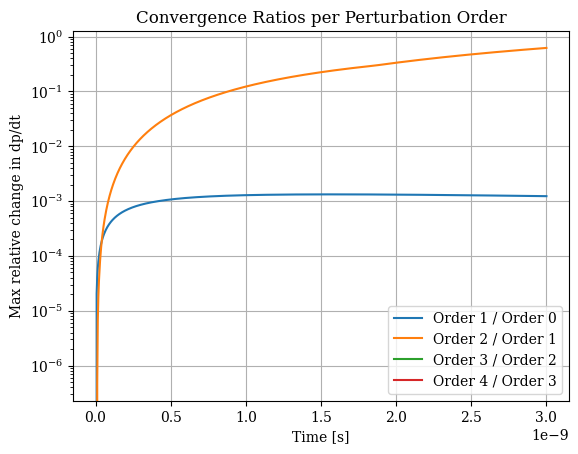

In [9]:
for k in range(K):
    plt.plot(times, convergence_ratios[:, k], label=f"Order {k+1} / Order {k}")
plt.yscale("log")
plt.xlabel("Time [s]")
plt.ylabel("Max relative change in dp/dt")
plt.title("Convergence Ratios per Perturbation Order")
plt.legend()
plt.grid()

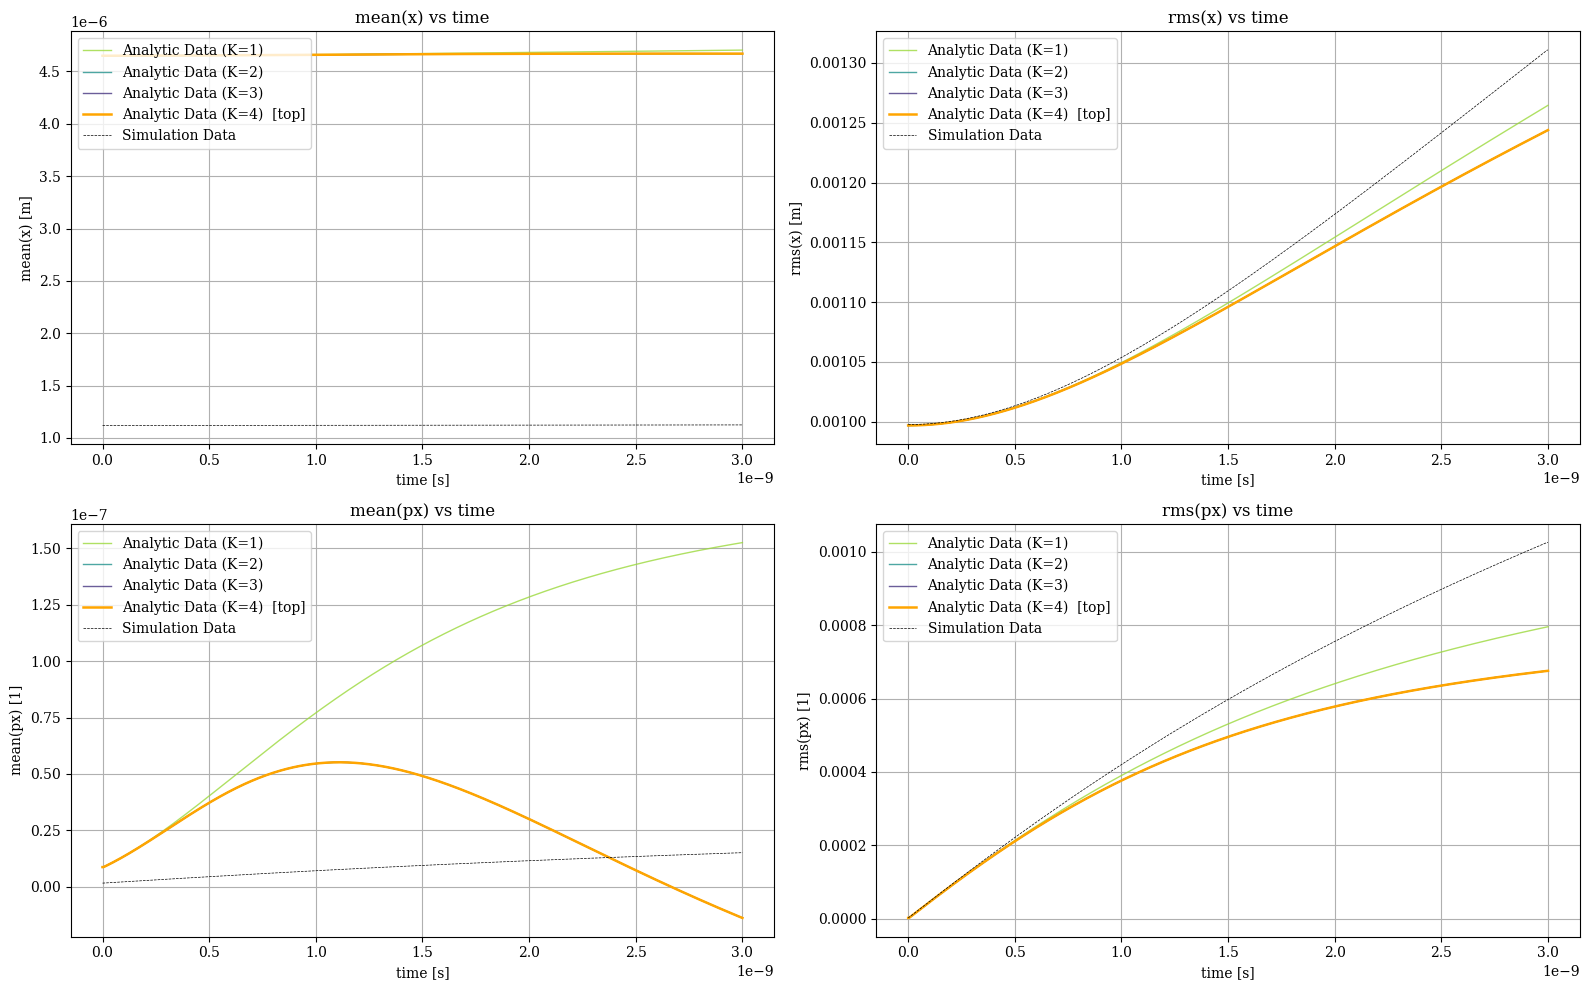

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

orders     = list(range(max(0, K - N_LOWER_ORDERS_TO_PLOT), K + 1))
plot_diff  = (len(orders) == 1)
_palette   = plt.cm.viridis(np.linspace(0.85, 0.15, max(len(orders) - 1, 1)))
_col_map   = {k: ('orange' if k == K else _palette[i])
              for i, k in enumerate(orders[:-1] + [K])}
_alpha     = lambda k: 1.0 if k == K else 0.8
_lw        = lambda k: 1.8 if k == K else 1.0
_col       = lambda k: _col_map[k]

for k in orders:
    lbl = f"Analytic Data (K={k})" + ("  [top]" if k == K else "")

    axes[0,0].plot(times, mean_r_orders[:, k, 0],                 color = _col(k), alpha=_alpha(k), linewidth=_lw(k), label=lbl)
    axes[0,1].plot(times, rms_r_orders [:, k, 0],                 color = _col(k), alpha=_alpha(k), linewidth=_lw(k), label=lbl)
    axes[1,0].plot(times, p_to_betagamma(mean_p_orders[:, k, 0]), color = _col(k), alpha=_alpha(k), linewidth=_lw(k), label=lbl)
    axes[1,1].plot(times, p_to_betagamma(rms_p_orders [:, k, 0]), color = _col(k), alpha=_alpha(k), linewidth=_lw(k), label=lbl)

for ax, ylabel, title in zip(
    axes.flat,
    ['mean(x) [m]', 'rms(x) [m]', 'mean(px) [1]', 'rms(px) [1]'],
    ['mean(x) vs time', 'rms(x) vs time', 'mean(px) vs time', 'rms(px) vs time'],
):
    ax.set_xlabel('time [s]')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid()
    ax.legend(loc='upper left')

plot_data(axes[0,0], times, mean_r_orders[:, K, 0],                 data_times, data_position_means_si [:, 0],                plot_diff=plot_diff)
plot_data(axes[0,1], times, rms_r_orders [:, K, 0],                 data_times, data_position_sigmas_si[:, 0],                plot_diff=plot_diff)
plot_data(axes[1,0], times, p_to_betagamma(mean_p_orders[:, K, 0]), data_times, p_to_betagamma(data_momentum_means_pp [:, 0]), plot_diff=plot_diff)
plot_data(axes[1,1], times, p_to_betagamma(rms_p_orders [:, K, 0]), data_times, p_to_betagamma(data_momentum_sigmas_pp[:, 0]), plot_diff=plot_diff)

fig.tight_layout()


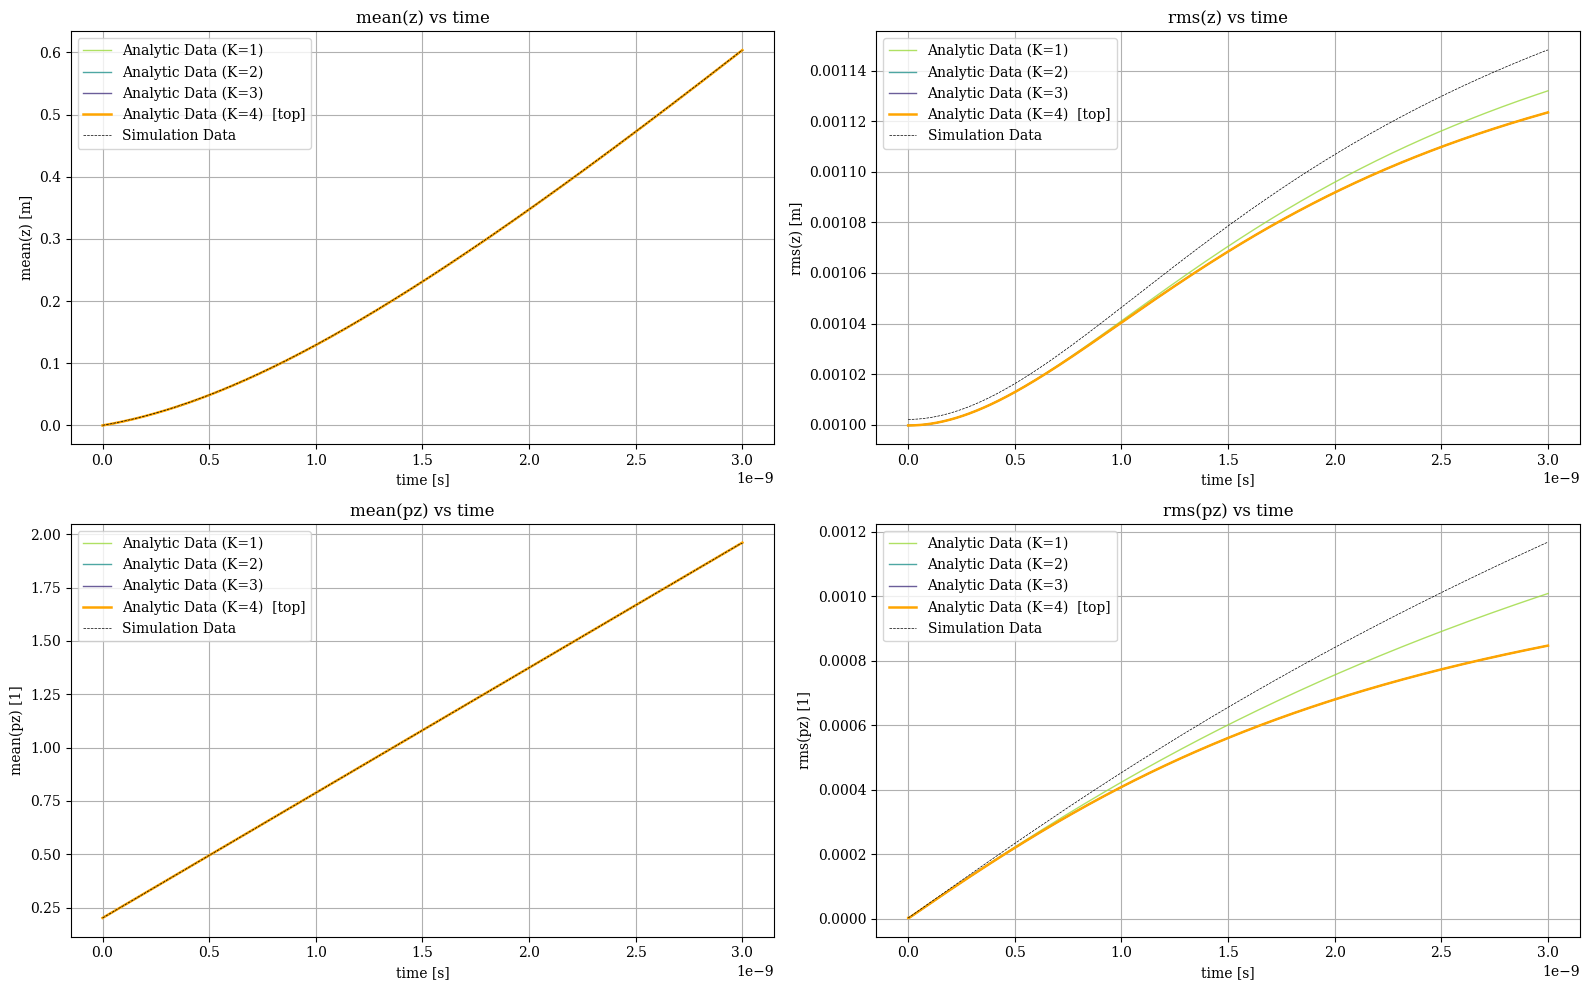

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for k in orders:
    lbl = f"Analytic Data (K={k})" + ("  [top]" if k == K else "")
    axes[0,0].plot(times, mean_r_orders[:, k, 2],                 color=_col(k), alpha=_alpha(k), linewidth=_lw(k), label=lbl)
    axes[0,1].plot(times, rms_r_orders [:, k, 2],                 color=_col(k), alpha=_alpha(k), linewidth=_lw(k), label=lbl)
    axes[1,0].plot(times, p_to_betagamma(mean_p_orders[:, k, 2]), color=_col(k), alpha=_alpha(k), linewidth=_lw(k), label=lbl)
    axes[1,1].plot(times, p_to_betagamma(rms_p_orders [:, k, 2]), color=_col(k), alpha=_alpha(k), linewidth=_lw(k), label=lbl)

for ax, ylabel, title in zip(
    axes.flat,
    ['mean(z) [m]', 'rms(z) [m]', 'mean(pz) [1]', 'rms(pz) [1]'],
    ['mean(z) vs time', 'rms(z) vs time', 'mean(pz) vs time', 'rms(pz) vs time'],
):
    ax.set_xlabel('time [s]')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid()
    ax.legend(loc='upper left')

plot_data(axes[0,0], times, mean_r_orders[:, K, 2],                 data_times, data_position_means_si [:, 2],                plot_diff=plot_diff)
plot_data(axes[0,1], times, rms_r_orders [:, K, 2],                 data_times, data_position_sigmas_si[:, 2],                plot_diff=plot_diff)
plot_data(axes[1,0], times, p_to_betagamma(mean_p_orders[:, K, 2]), data_times, p_to_betagamma(data_momentum_means_pp [:, 2]), plot_diff=plot_diff)
plot_data(axes[1,1], times, p_to_betagamma(rms_p_orders [:, K, 2]), data_times, p_to_betagamma(data_momentum_sigmas_pp[:, 2]), plot_diff=plot_diff)

fig.tight_layout()